<a href="https://colab.research.google.com/github/Sherlysukmadira/2311532015_Sherly-Sukmadira-Putri_ImageProcessing/blob/main/Telco_Customer_Churn_%7C%7C_Tb_Prak_BIG_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA TELCO CUSTOMER CHURN
Dataset yang digunakan merupakan data pelanggan dari industri telekomunikasi yang berisi informasi terkait karakteristik, penggunaan layanan, serta status pelanggan. Dataset ini berasal dari platform Kaggle dengan judul Telecom Customer Churn oleh Maven Analytics.

Data mencakup berbagai variabel seperti demografi pelanggan (misalnya usia, status pernikahan), informasi layanan (jenis internet, layanan tambahan seperti streaming atau keamanan), serta perilaku penggunaan (tenure, biaya bulanan). Target utama dalam dataset ini adalah Customer Status, yang menunjukkan apakah pelanggan tetap menggunakan layanan (Stayed) atau berhenti (Churned).

Tujuan analisis pada dataset ini adalah untuk membangun model machine learning yang mampu memprediksi kemungkinan pelanggan churn, sehingga perusahaan dapat mengambil langkah preventif untuk meningkatkan retensi pelanggan.

# Library

In [ ]:
# 1. Pengolahan data
import pandas as pd
import numpy as np
from scipy import stats

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# filter warnings
import warnings
warnings.filterwarnings('ignore')

# **READ DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Project DS/Salinan telecom_customer_churn.csv')

# **EDA**

In [ ]:
#Cek Struktur Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

INSIGHT :
1. Data terdiri dari 37 fitur(kolom) dengan tipe data campuran antara numerik dan kategorikal.
2. Terdapat perbedaaan jumlah data di setiap fitur hal ini mengindikasikan adanya missng value pada kolom-kolom tertentu di dalam data


In [ ]:
#Statistik Deskriptif
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [ ]:
#Cek apakah ada nilai negatif
df[df['Monthly Charge'] < 0]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
32,0052-DCKON,Male,28,Yes,0,Los Angeles,90063,34.044271,-118.185237,9,...,Bank Withdrawal,-2.0,7942.15,0.00,0,2888.82,10830.97,Stayed,NaN,NaN
170,0274-JKUJR,Male,21,Yes,2,Los Angeles,90040,33.994524,-118.149953,9,...,Credit Card,-3.0,465.70,0.00,0,0.00,465.70,Stayed,NaN,NaN
232,0361-HJRDX,Female,38,No,0,Sherman Oaks,91403,34.147149,-118.463365,0,...,Credit Card,-8.0,4539.60,0.00,130,0.00,4669.60,Stayed,NaN,NaN
336,0495-ZBNGW,Male,78,Yes,0,Loma Mar,94021,37.266388,-122.263080,1,...,Bank Withdrawal,-1.0,343.95,0.00,20,33.30,397.25,Churned,Competitor,Competitor offered more data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,9793-WECQC,Male,53,No,0,Foresthill,95631,39.031876,-120.811141,0,...,Credit Card,-1.0,2192.90,0.00,0,1108.83,3301.73,Stayed,NaN,NaN
6918,9821-BESNZ,Male,43,No,0,Northridge,91325,34.236683,-118.517588,0,...,Bank Withdrawal,-7.0,6860.60,44.00,0,2179.32,8995.92,Stayed,NaN,NaN
6976,9898-KZQDZ,Female,65,Yes,0,Lee Vining,93541,37.890145,-119.184087,1,...,Credit Card,-1.0,3640.45,0.00,0,1980.00,5620.45,Churned,Competitor,Competitor had better devices
7020,9961-JBNMK,Male,79,No,0,Desert Center,92239,33.889605,-115.257009,0,...,Bank Withdrawal,-1.0,2030.30,10.20,0,887.67,2907.77,Churned,Dissatisfaction,Product dissatisfaction


Insight :
Terdapat kejangalan pada kolom Monthly Charge dimana terdapt beberapa data yang bernilai negatif.

In [ ]:
#Lihat jumlah data bernilai negatif
(df['Monthly Charge'] < 0).sum()

np.int64(120)

# Cek Missing Value

Ditemukan 120 data dengan nilai negatif pada fitur Monthly Charge yang tidak sesuai secara logika bisnis.

In [ ]:
#cek total missing value
df.isnull().sum().sort_values(ascending=False)

,0
Churn Reason,5174
Churn Category,5174
Offer,3877
Online Backup,1526
Avg Monthly GB Download,1526
Online Security,1526
Streaming Movies,1526
Streaming TV,1526
Unlimited Data,1526
Streaming Music,1526


Indight :
1. Terdapat mssing value di 15 fitur pada data
2. Missng value pada fitur Churn Reason dan Churn Category bukan lah data yang rusak.  Missing value pada fitur ini terjadi karena informasi tersebut hanya tersedia untuk pelanggan yang melakukan churn dengan kata lain pelanggan yang tidak churn maka kolomnya akan kosong
3. Missing value pada fitur Offer menunjukkan bahwa sebagian besar pelanggan tidak menerima atau tidak menggunakan penawaran/promosi tertentu
4. Missing value pada fitur ini kemungkinan berasal dari pelanggan yang tidak menggunakan layanan telepon jarak jauh
5. Missing value untuk data lainnya (Online, Backup,Online Security,Streaming, Avg Monthl, dll) kemungkinan terjadi karena pelanggan tidak menggunakan layanan internet

In [ ]:
#Membuktikan poin 5
df['Internet Service'].value_counts()

,count
Internet Service,
Yes,5517
No,1526


Dapat terlihat bahwa customer yang tidak menggunakan layanan terdiri dari 1526 customer di mana angka ini sama dengan jumlah missing value pada fitur berikut :
1. Online Backup
2. Online Security
3. Streaming (TV, Movies, Music)
4. Unlimited Data
5. Internet Type
6. Device Protection Plan
7. Premium Tech Support
8. Avg Monthly GB Download

INSIGHT DARI SEMUA MISSING VALUE

Sebagian besar missing value dalam dataset bukan disebabkan oleh kesalahan data, melainkan karena ketidakterlibatan pelanggan dalam layanan tertentu. Hal ini menunjukkan bahwa missing value bersifat informatif dan mencerminkan perilaku pelanggan, seperti tidak menggunakan layanan internet atau tidak menerima penawaran tertentu.

# Lihat hubungan Antar Data

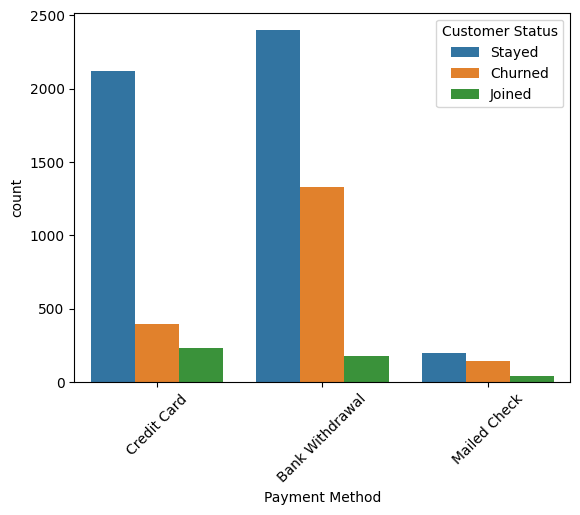

In [ ]:
#Churn vs Contract / Payment
sns.countplot(x='Payment Method', hue='Customer Status', data=df)
plt.xticks(rotation=45)
plt.show()

Kebanyakan customer yang bertahan menggunakan payment method Bank Withdrawal kemudian payment method yang kedua digunakan oleh pengguna yang bertahan ialah credit card.

Sementara Mailed Check sangat jarang digunanakan oleh semua pengguna baik yang memiliki satatus stayed, churned, maupun joined. Hal ini mengindikasikan bahwa metode pembayaran mailed check kurang relevan untuk digunakan customer

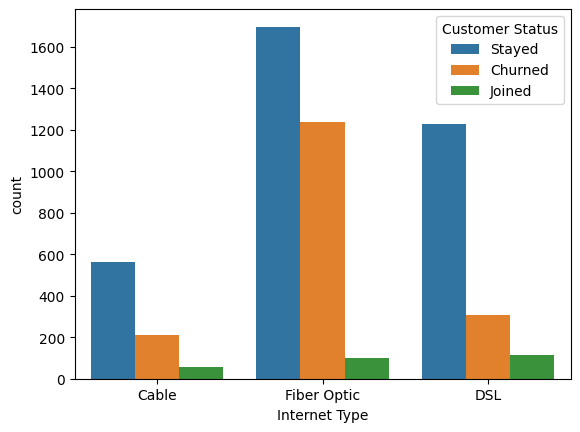

In [ ]:
#Churn vs Internet Type
sns.countplot(x='Internet Type', hue='Customer Status', data=df)
plt.show()

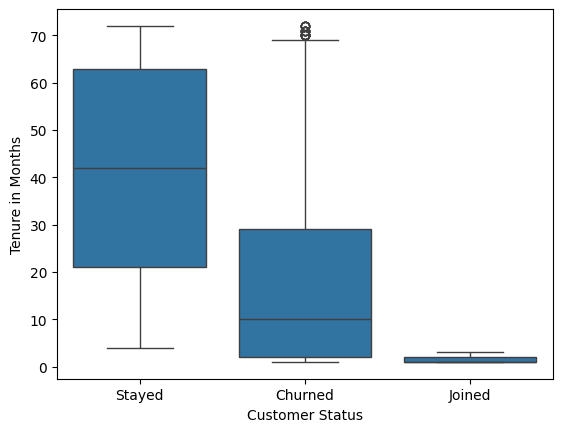

In [ ]:
#Churn vs Tenure
sns.boxplot(x='Customer Status', y='Tenure in Months', data=df)
plt.show()

Insight : Customer baru lebih sering churn dan terdapat sedikit outlier pada fitur churn customer status

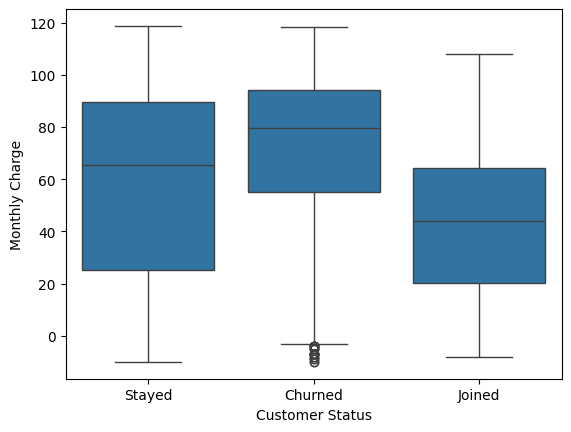

In [ ]:
#Churn vs Monthly Charge
sns.boxplot(x='Customer Status', y='Monthly Charge', data=df)
plt.show()

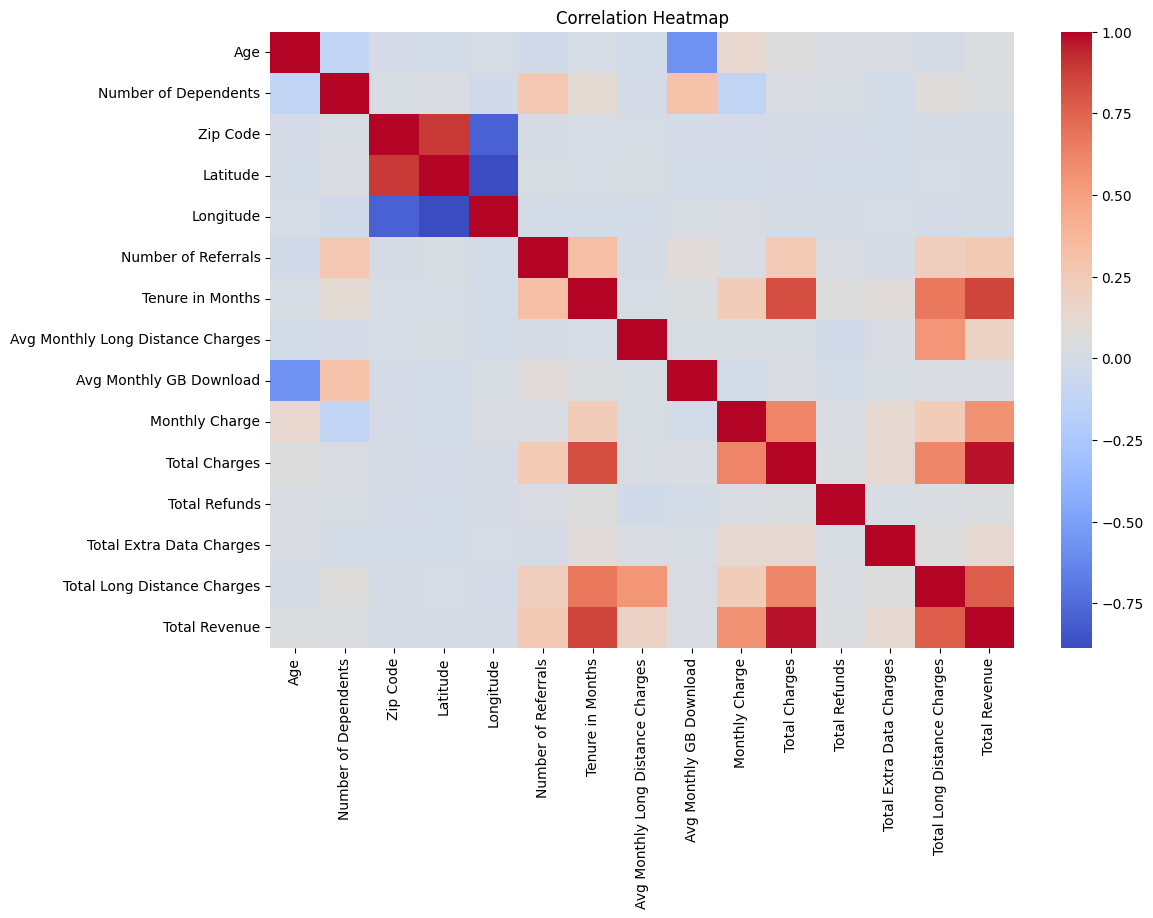

In [ ]:
#Heatmap untuk data numerik
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Berdasarkan korelasi pada heatmap tersebut, faktor yang paling kuat memengaruhi Total Revenue adalah Tenure in Months dan Total Charges, yang mengindikasikan bahwa semakin lama pelanggan berlangganan, semakin besar kontribusi pendapatan yang mereka berikan

In [ ]:
#cek hubungan antar data kategori
pd.crosstab(df['Payment Method'], df['Customer Status'], normalize='index')

Customer Status,Churned,Joined,Stayed
Payment Method,,,
Bank Withdrawal,0.339985,0.046303,0.613712
Credit Card,0.144780,0.084031,0.771190
Mailed Check,0.368831,0.109091,0.522078


Insight : Credit card sangan dekat hubungannya dengan stayed. Sehinnga perusahaan perlu memastikan  metode pembayaran yang paling disukai customer

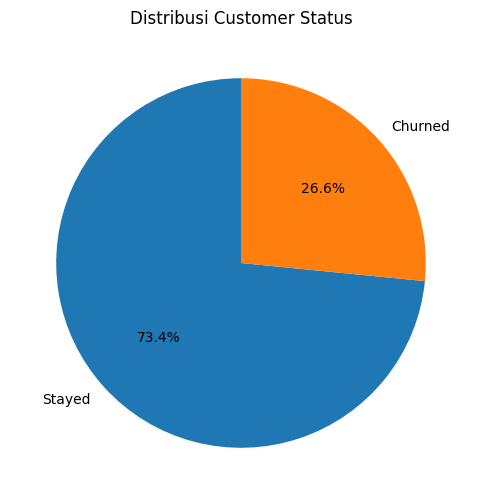

In [ ]:
#Lihat distribusi fitur churn dan tidak churn
import matplotlib.pyplot as plt

churn_counts = y.value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribusi Customer Status")
plt.show()

Data tidak seimbang sehingga perlu dilakukan penanganan imbalanced data

# **CLEANING**

In [ ]:
#kopi data terkebih dahulu agar data tetap aman dan bersih
df_clean = df.copy()

In [ ]:
#Handle Monthly Charge Negatif
df_clean = df_clean[df_clean['Monthly Charge'] >= 0]

Nilai negatif pada Monthly Charge dihapus karena tidak sesuai dengan logika bisnis.

In [ ]:
#Handle Missing Value pada fitur churn Reason dan schurn Category
df_clean['Churn Reason'] = df_clean['Churn Reason'].fillna('No Churn')
df_clean['Churn Category'] = df_clean['Churn Category'].fillna('No Churn')

In [ ]:
#Handle missing value pada layanan internet
internet_cols = [
    'Online Backup','Online Security','Streaming Movies','Streaming TV',
    'Streaming Music','Unlimited Data','Device Protection Plan',
    'Premium Tech Support','Internet Type', 'Multiple Lines'
]

for col in internet_cols:
    df_clean[col] = df_clean[col].fillna('No Service')

In [ ]:
df_clean['Avg Monthly GB Download'] = df_clean['Avg Monthly GB Download'].fillna(0)

In [ ]:
df_clean['Offer'] = df_clean['Offer'].fillna('No Offer')

In [ ]:
df_clean['Avg Monthly Long Distance Charges'] = df_clean['Avg Monthly Long Distance Charges'].fillna(0)

In [ ]:
#Drop kolom yang tidak relevan
df_clean = df_clean.drop(['Customer ID', 'Zip Code', 'Latitude', 'Longitude'], axis=1)

In [ ]:
#Cek ulang missing value
df_clean.isnull().sum()


,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0


In [ ]:
#Cek duplikasi
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
#Cek tipe data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6923 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             6923 non-null   object 
 1   Age                                6923 non-null   int64  
 2   Married                            6923 non-null   object 
 3   Number of Dependents               6923 non-null   int64  
 4   City                               6923 non-null   object 
 5   Number of Referrals                6923 non-null   int64  
 6   Tenure in Months                   6923 non-null   int64  
 7   Offer                              6923 non-null   object 
 8   Phone Service                      6923 non-null   object 
 9   Avg Monthly Long Distance Charges  6923 non-null   float64
 10  Multiple Lines                     6252 non-null   object 
 11  Internet Service                   6923 non-null   object 
 1

# **ENCODING**
Encoding dilakukan untuk mengubah data kategorikal menjadi numerik agar dapat diproses oleh algoritma machine learning.

In [ ]:
df_clean['Customer Status'] = df_clean['Customer Status'].fillna(0)

In [ ]:
X = df_clean.drop('Customer Status', axis=1)
y = df_clean['Customer Status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Customer Status,
0.0,0.734381
1.0,0.265619


In [ ]:
X.columns.tolist()

['Gender',
 'Age',
 'Married',
 'Number of Dependents',
 'City',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue']

In [ ]:
drop_cols = [
    'Customer Status',
    'Churn Category',
    'Churn Reason',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue'
]

X = df_clean.drop(columns=drop_cols, errors='ignore')
y = df_clean['Customer Status']

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **MODELLING**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Simpan hasil
model_results = []

#kita coba beberapa model dan bandingkan mana yang terbaik
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced'),
     {'model__C': [0.1, 1, 10]}),

    ('Random Forest', RandomForestClassifier(random_state=42),
     {'model__n_estimators': [100, 200],
      'model__max_depth': [None, 10]}),

    ('Gradient Boosting', GradientBoostingClassifier(random_state=42),
     {'model__n_estimators': [100],
      'model__learning_rate': [0.05, 0.1]}),

    ('SVM', SVC(class_weight='balanced'),
     {'model__C': [1, 10]}),

    ('KNN', KNeighborsClassifier(),
     {'model__n_neighbors': [5, 7]}),

    ('Decision Tree', DecisionTreeClassifier(random_state=42),
     {'model__max_depth': [None, 10]}),

    ('AdaBoost', AdaBoostClassifier(random_state=42),
     {'model__n_estimators': [100]}),

    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
     {'model__n_estimators': [100],
      'model__learning_rate': [0.1]}),

    ('Naive Bayes', GaussianNB(), {})
]

best_model = None
best_recall = 0

for name, model, param_grid in models:

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    if param_grid:
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=3,
            scoring='recall',   # 🔥 fokus ke churn detection
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_pipeline = grid.best_estimator_
    else:
        best_pipeline = pipeline
        best_pipeline.fit(X_train, y_train)

    y_pred = best_pipeline.predict(X_test)

    recall = recall_score(y_test, y_pred)

    print(f"\nModel: {name}")
    print("Recall (Churn):", round(recall, 3))
    print(classification_report(y_test, y_pred))

    model_results.append({
        'Model': name,
        'Recall': recall
    })

    if recall > best_recall:
        best_recall = recall
        best_model = best_pipeline

# hasil akhir
import pandas as pd

results_df = pd.DataFrame(model_results).sort_values(by='Recall', ascending=False)

print("\n=== MODEL COMPARISON ===")
print(results_df)

print("\n=== BEST MODEL ===")
print(best_model)
print("Best Recall:", best_recall)


Model: Logistic Regression
Recall (Churn): 0.851
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84      1017
         1.0       0.57      0.85      0.68       368

    accuracy                           0.79      1385
   macro avg       0.75      0.81      0.76      1385
weighted avg       0.84      0.79      0.80      1385


Model: Random Forest
Recall (Churn): 0.582
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89      1017
         1.0       0.73      0.58      0.65       368

    accuracy                           0.83      1385
   macro avg       0.80      0.75      0.77      1385
weighted avg       0.83      0.83      0.83      1385


Model: Gradient Boosting
Recall (Churn): 0.66
              precision    recall  f1-score   support

         0.0       0.88      0.92      0.90      1017
         1.0       0.76      0.66      0.71       368

    accuracy                           0.

Model Logistic Regression menunjukkan kemampuan yang sangat baik dalam mendeteksi pelanggan churn dengan nilai recall sebesar 85%. Meskipun precision relatif lebih rendah, model ini efektif digunakan dalam strategi retensi pelanggan karena mampu mengidentifikasi sebagian besar pelanggan yang berisiko churn.